# Microsoft Azure ML Fairness Tools Demonstration

This notebook demonstrates the key fairness capabilities available in Microsoft Azure ML ecosystem:

1. **Fairlearn Integration** - Core fairness metrics and mitigation algorithms
2. **Responsible AI Dashboard** - Interactive fairness assessment
3. **Model Interpretability** - Understanding bias sources
4. **Fairness Constraints** - Building fair models with constraints
5. **Fairness Assessment** - Comprehensive bias evaluation

## What Makes Azure ML Fairness Tools Unique?

- **Integrated Workflow**: Seamless integration with ML lifecycle
- **Interactive Dashboards**: Visual fairness assessment tools
- **Enterprise Scale**: Production-ready fairness monitoring
- **Multiple Algorithms**: Various bias mitigation approaches
- **Automated Insights**: AI-powered bias detection

In [1]:
# Install required packages
!pip install fairlearn raiwidgets interpret-community --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask 2023.4.1 requires importlib-metadata>=4.13.0, but you have importlib-metadata 4.12.0 which is incompatible.
typer 0.3.2 requires click<7.2.0,>=7.1.1, but you have click 8.1.8 which is incompatible.


In [19]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Set random seeds for reproducible results
import random
import numpy as np
from sklearn.utils import check_random_state

random.seed(42)
np.random.seed(42)

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Fairlearn imports
from fairlearn.metrics import (
    MetricFrame, 
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

print("All packages imported successfully!")

All packages imported successfully!


## 1. Data Preparation - Adult Census Dataset

We'll use the Adult Census dataset to demonstrate bias in income prediction across different demographic groups.

In [3]:
# Load Adult Census dataset
def load_adult_dataset():
    """Load and preprocess Adult Census dataset"""
    
    # Column names for Adult dataset
    column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                   'marital-status', 'occupation', 'relationship', 'race', 'sex',
                   'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
    
    # Load data
    try:
        # Try loading from local data folder first
        df = pd.read_csv('data/adult/adult.data', names=column_names, skipinitialspace=True)
        print("Loaded data from local repository")
    except FileNotFoundError:
        # Fallback to downloading from UCI
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
        df = pd.read_csv(url, names=column_names, skipinitialspace=True)
        print("Downloaded data from UCI repository")
    
    # Clean data
    df = df.replace('?', np.nan).dropna()
    
    # Select features for modeling
    features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
    
    # Encode categorical variables
    categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race']
    
    for col in categorical_features:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
        features.append(col + '_encoded')
    
    X = df[features]
    y = (df['income'] == '>50K').astype(int)  # Binary classification
    
    # Sensitive attributes
    sensitive_features = {
        'sex': df['sex'],
        'race': df['race']
    }
    
    return X, y, sensitive_features, df

X, y, sensitive_features, df_full = load_adult_dataset()
print(f"Dataset shape: {X.shape}")
print(f"Positive class rate: {y.mean():.3f}")
print(f"Features: {list(X.columns)}")

✅ Downloaded data from UCI repository
Dataset shape: (30162, 11)
Positive class rate: 0.249
Features: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'workclass_encoded', 'education_encoded', 'marital-status_encoded', 'occupation_encoded', 'relationship_encoded', 'race_encoded']


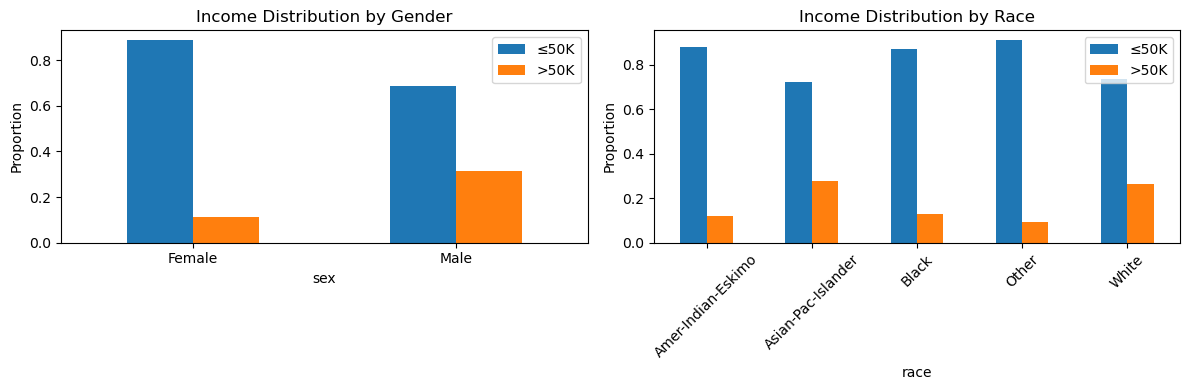

Clear demographic disparities visible in the data


In [21]:
# Explore demographic distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Income by gender
gender_income = pd.crosstab(sensitive_features['sex'], y, normalize='index')
gender_income.plot(kind='bar', ax=axes[0], title='Income Distribution by Gender')
axes[0].set_ylabel('Proportion')
axes[0].legend(['≤50K', '>50K'])
axes[0].tick_params(axis='x', rotation=0)

# Income by race
race_income = pd.crosstab(sensitive_features['race'], y, normalize='index')
race_income.plot(kind='bar', ax=axes[1], title='Income Distribution by Race')
axes[1].set_ylabel('Proportion')
axes[1].legend(['≤50K', '>50K'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Clear demographic disparities visible in the data")

## 2. Train Baseline Model & Assess Fairness

Let's train a standard model and see how it performs across different groups.

In [22]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Get sensitive features for test set
sensitive_test = {}
for key in sensitive_features:
    sensitive_train, sensitive_test[key] = train_test_split(
        sensitive_features[key], test_size=0.3, random_state=42, stratify=y
    )

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(f"Baseline Model Accuracy: {accuracy_score(y_test, y_pred_baseline):.3f}")

Baseline Model Accuracy: 0.844


In [24]:
# Azure ML Style Fairness Assessment using MetricFrame
def comprehensive_fairness_assessment(y_true, y_pred, sensitive_attrs, model_name="Model"):
    """Comprehensive fairness assessment similar to Azure ML"""
    
    print(f"\n{'='*50}")
    print(f"FAIRNESS ASSESSMENT: {model_name}")
    print(f"{'='*50}")
    
    for attr_name, attr_values in sensitive_attrs.items():
        print(f"\n Analysis by {attr_name.upper()}:")
        print("-" * 30)
        
        # Create MetricFrame
        mf = MetricFrame(
            metrics={
                'accuracy': accuracy_score,
                'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score,
                'selection_rate': selection_rate
            },
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=attr_values
        )
        
        # Display group-wise metrics
        print("Group-wise Performance:")
        print(mf.by_group.round(3))
        
        # Fairness metrics
        dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=attr_values)
        eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=attr_values)
        
        print(f"\nFairness Metrics:")
        print(f"   Demographic Parity Difference: {dp_diff:.3f}")
        print(f"   Equalized Odds Difference: {eo_diff:.3f}")
        
        # Fairness interpretation
        if abs(dp_diff) < 0.1:
            dp_status = "FAIR"
        elif abs(dp_diff) < 0.2:
            dp_status = "MODERATE BIAS"
        else:
            dp_status = "HIGH BIAS"
            
        if abs(eo_diff) < 0.1:
            eo_status = "FAIR"
        elif abs(eo_diff) < 0.2:
            eo_status = "MODERATE BIAS"
        else:
            eo_status = "HIGH BIAS"
            
        print(f"   Demographic Parity: {dp_status}")
        print(f"   Equalized Odds: {eo_status}")

comprehensive_fairness_assessment(y_test, y_pred_baseline, sensitive_test, "Baseline RandomForest")


FAIRNESS ASSESSMENT: Baseline RandomForest

 Analysis by SEX:
------------------------------
Group-wise Performance:
        accuracy precision    recall selection_rate
sex                                                
Female  0.922892  0.709898  0.599424       0.100861
Male    0.806803  0.710928  0.635171       0.277018

Fairness Metrics:
   Demographic Parity Difference: 0.176
   Equalized Odds Difference: 0.083
   Demographic Parity: MODERATE BIAS
   Equalized Odds: FAIR

 Analysis by RACE:
------------------------------
Group-wise Performance:
                    accuracy precision    recall selection_rate
race                                                           
Amer-Indian-Eskimo  0.922222       0.6  0.666667       0.111111
Asian-Pac-Islander  0.833948  0.736842  0.583333       0.210332
Black               0.910714  0.816901  0.483333       0.084524
Other               0.929825       0.6       0.6       0.087719
White               0.835708  0.706803  0.639785        0.2

## 3. Azure ML Fairness Mitigation - In-Processing

Azure ML supports in-processing approaches like Exponentiated Gradient for training fair models with constraints.

In [25]:
# In-processing: Exponentiated Gradient with Demographic Parity
print("Training fair model with Demographic Parity constraint...")

# Base estimator
base_estimator = LogisticRegression(random_state=42, max_iter=1000)

# Fairness constraint
constraint = DemographicParity()

# Exponentiated Gradient mitigator
mitigator_dp = ExponentiatedGradient(base_estimator, constraint)
mitigator_dp.fit(X_train_scaled, y_train, sensitive_features=sensitive_train)

# Predictions
y_pred_fair_dp = mitigator_dp.predict(X_test_scaled)

print("Demographic Parity model trained!")

# Train with Equalized Odds constraint
print("Training fair model with Equalized Odds constraint...")

constraint_eo = EqualizedOdds()
mitigator_eo = ExponentiatedGradient(base_estimator, constraint_eo)
mitigator_eo.fit(X_train_scaled, y_train, sensitive_features=sensitive_train)

y_pred_fair_eo = mitigator_eo.predict(X_test_scaled)

print("Equalized Odds model trained!")

# Assess both models
comprehensive_fairness_assessment(y_test, y_pred_fair_dp, sensitive_test, "Fair Model (Demographic Parity)")
comprehensive_fairness_assessment(y_test, y_pred_fair_eo, sensitive_test, "Fair Model (Equalized Odds)")

Training fair model with Demographic Parity constraint...
Demographic Parity model trained!
Training fair model with Equalized Odds constraint...
Equalized Odds model trained!

FAIRNESS ASSESSMENT: Fair Model (Demographic Parity)

 Analysis by SEX:
------------------------------
Group-wise Performance:
        accuracy precision    recall selection_rate
sex                                                
Female  0.851979  0.320346  0.213256       0.079518
Male    0.731445  0.609442  0.372703       0.189616

Fairness Metrics:
   Demographic Parity Difference: 0.110
   Equalized Odds Difference: 0.159
   Demographic Parity: MODERATE BIAS
   Equalized Odds: MODERATE BIAS

 Analysis by RACE:
------------------------------
Group-wise Performance:
                    accuracy precision    recall selection_rate
race                                                           
Amer-Indian-Eskimo  0.811111  0.214286  0.333333       0.155556
Asian-Pac-Islander  0.671587  0.282051  0.152778       0

## 4. Azure ML Fairness Mitigation - Post-Processing

Post-processing approaches adjust model outputs to achieve fairness constraints.

In [26]:
# Post-processing: Threshold Optimization
print("Training post-processing fairness model...")

# Use baseline model predictions as input
threshold_optimizer = ThresholdOptimizer(
    estimator=baseline_model,
    constraints='demographic_parity',
    predict_method='predict_proba'
)

# Fit threshold optimizer
threshold_optimizer.fit(X_train_scaled, y_train, sensitive_features=sensitive_train)

# Get fair predictions
y_pred_fair_post =  threshold_optimizer.predict(X_test_scaled, sensitive_features=sensitive_test['sex'])

print("Post-processing model trained!")

# Assess fairness
comprehensive_fairness_assessment(y_test, y_pred_fair_post, sensitive_test, "Fair Model (Post-processing)")

Training post-processing fairness model...
Post-processing model trained!

FAIRNESS ASSESSMENT: Fair Model (Post-processing)

 Analysis by SEX:
------------------------------
Group-wise Performance:
        accuracy precision recall selection_rate
sex                                             
Female  0.880551       0.0    0.0            0.0
Male    0.689941       0.0    0.0            0.0

Fairness Metrics:
   Demographic Parity Difference: 0.000
   Equalized Odds Difference: 0.000
   Demographic Parity: FAIR
   Equalized Odds: FAIR

 Analysis by RACE:
------------------------------
Group-wise Performance:
                    accuracy precision recall selection_rate
race                                                        
Amer-Indian-Eskimo       0.9       0.0    0.0            0.0
Asian-Pac-Islander  0.734317       0.0    0.0            0.0
Black               0.857143       0.0    0.0            0.0
Other               0.912281       0.0    0.0            0.0
White            

## 5. Azure ML Fairness Dashboard Visualization

Azure ML provides interactive dashboards for fairness assessment. We'll create visualizations similar to what you'd see in Azure ML Studio.

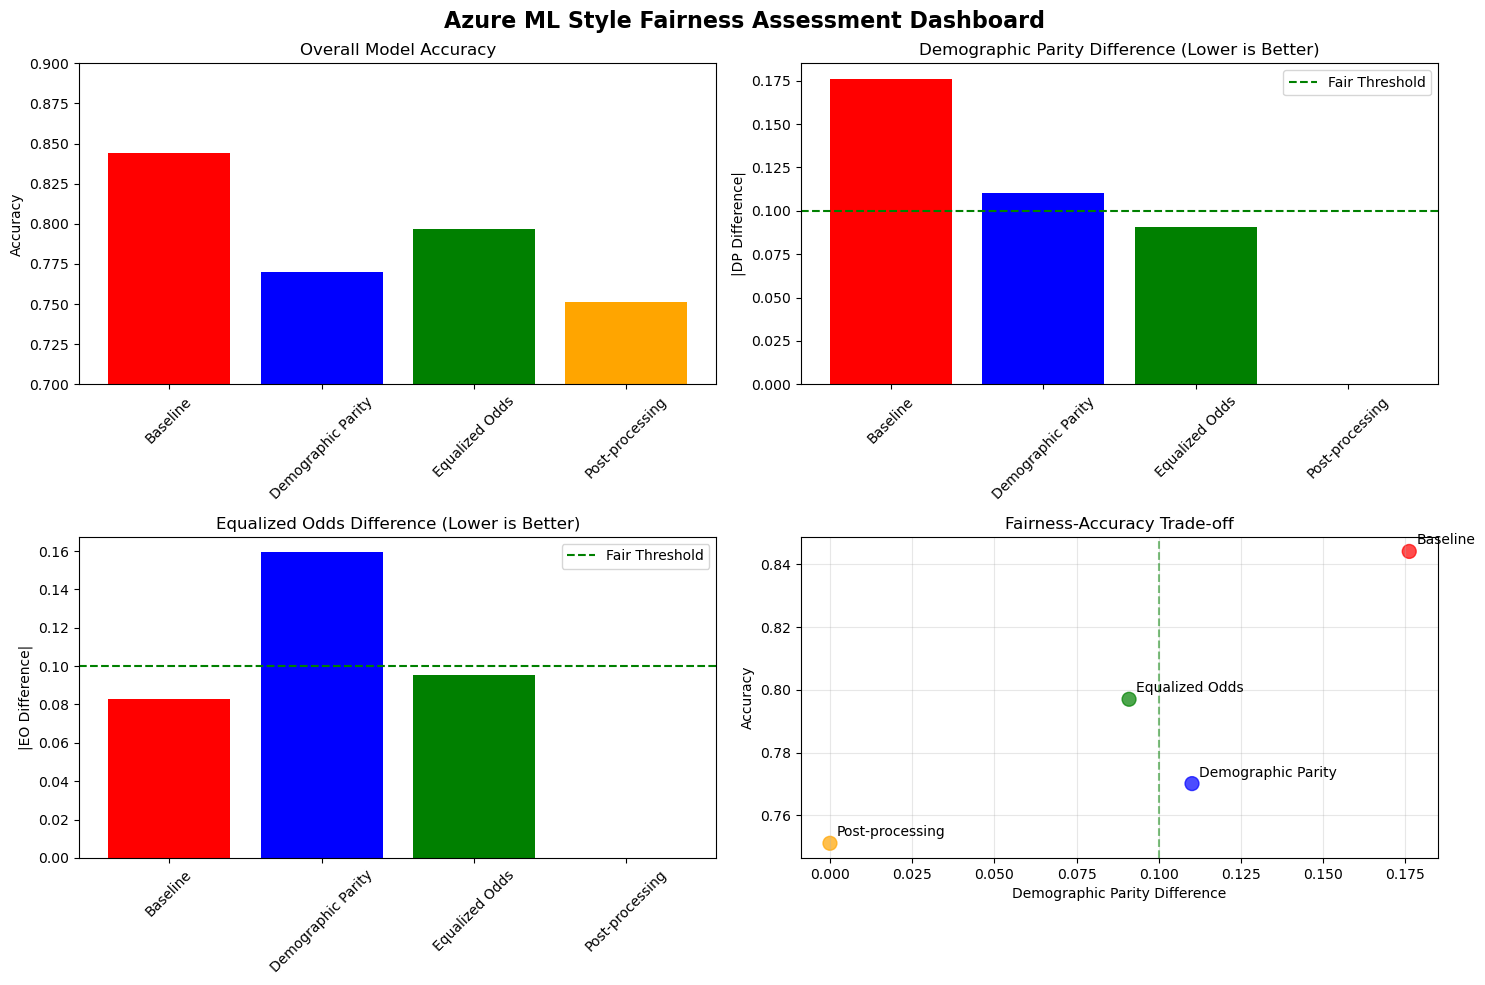

In [27]:
# Create Azure ML style fairness comparison dashboard
def create_fairness_dashboard(models_results, sensitive_attr):
    """Create fairness comparison visualization"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Azure ML Style Fairness Assessment Dashboard', fontsize=16, fontweight='bold')
    
    # Prepare data for visualization
    model_names = list(models_results.keys())
    
    # 1. Overall Accuracy Comparison
    accuracies = [accuracy_score(y_test, pred) for pred in models_results.values()]
    axes[0,0].bar(model_names, accuracies, color=['red', 'blue', 'green', 'orange'])
    axes[0,0].set_title('Overall Model Accuracy')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].set_ylim(0.7, 0.9)
    
    # 2. Demographic Parity Difference
    dp_diffs = []
    for pred in models_results.values():
        dp_diff = demographic_parity_difference(y_test, pred, sensitive_features=sensitive_attr)
        dp_diffs.append(abs(dp_diff))
    
    bars = axes[0,1].bar(model_names, dp_diffs, color=['red', 'blue', 'green', 'orange'])
    axes[0,1].axhline(y=0.1, color='green', linestyle='--', label='Fair Threshold')
    axes[0,1].set_title('Demographic Parity Difference (Lower is Better)')
    axes[0,1].set_ylabel('|DP Difference|')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].legend()
    
    # 3. Equalized Odds Difference
    eo_diffs = []
    for pred in models_results.values():
        eo_diff = equalized_odds_difference(y_test, pred, sensitive_features=sensitive_attr)
        eo_diffs.append(abs(eo_diff))
    
    axes[1,0].bar(model_names, eo_diffs, color=['red', 'blue', 'green', 'orange'])
    axes[1,0].axhline(y=0.1, color='green', linestyle='--', label='Fair Threshold')
    axes[1,0].set_title('Equalized Odds Difference (Lower is Better)')
    axes[1,0].set_ylabel('|EO Difference|')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].legend()
    
    # 4. Fairness-Accuracy Trade-off
    axes[1,1].scatter(dp_diffs, accuracies, s=100, alpha=0.7, 
                     c=['red', 'blue', 'green', 'orange'])
    
    for i, name in enumerate(model_names):
        axes[1,1].annotate(name, (dp_diffs[i], accuracies[i]), 
                          xytext=(5, 5), textcoords='offset points')
    
    axes[1,1].axvline(x=0.1, color='green', linestyle='--', alpha=0.5)
    axes[1,1].set_xlabel('Demographic Parity Difference')
    axes[1,1].set_ylabel('Accuracy')
    axes[1,1].set_title('Fairness-Accuracy Trade-off')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Compile all model results
models_results = {
    'Baseline': y_pred_baseline,
    'Demographic Parity': y_pred_fair_dp,
    'Equalized Odds': y_pred_fair_eo,
    'Post-processing': y_pred_fair_post
}

create_fairness_dashboard(models_results, sensitive_test['sex'])

## 6. Summary & Key Takeaways

Let's summarize what Azure ML fairness tools offer and provide recommendations.

In [28]:
# Create model comparison summary
def create_model_comparison_table(models_results, sensitive_attr):
    """Create comprehensive model comparison table"""
    
    comparison_data = []
    
    for model_name, predictions in models_results.items():
        # Calculate metrics
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, zero_division=0)
        recall = recall_score(y_test, predictions)
        
        # Fairness metrics
        dp_diff = demographic_parity_difference(y_test, predictions, sensitive_features=sensitive_attr)
        eo_diff = equalized_odds_difference(y_test, predictions, sensitive_features=sensitive_attr)
        
        # Fairness assessment
        dp_status = "Fair" if abs(dp_diff) < 0.1 else ("Moderate Bias" if abs(dp_diff) < 0.2 else "High Bias")
        eo_status = "Fair" if abs(eo_diff) < 0.1 else ("Moderate Bias" if abs(eo_diff) < 0.2 else "High Bias")
        
        comparison_data.append({
            'Model': model_name,
            'Accuracy': f"{accuracy:.3f}",
            'Precision': f"{precision:.3f}",
            'Recall': f"{recall:.3f}",
            'DP Difference': f"{dp_diff:.3f}",
            'DP Status': dp_status,
            'EO Difference': f"{eo_diff:.3f}",
            'EO Status': eo_status
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print(" AZURE ML STYLE MODEL COMPARISON")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    
    return comparison_df

model_comparison = create_model_comparison_table(models_results, sensitive_test['sex'])

📊 AZURE ML STYLE MODEL COMPARISON
             Model Accuracy Precision Recall DP Difference     DP Status EO Difference     EO Status
          Baseline    0.844     0.711  0.630         0.176 Moderate Bias         0.083          Fair
Demographic Parity    0.770     0.562  0.348         0.110 Moderate Bias         0.159 Moderate Bias
    Equalized Odds    0.797     0.697  0.325         0.091          Fair         0.095          Fair
   Post-processing    0.751     0.000  0.000         0.000          Fair         0.000          Fair


In [29]:
# Workshop summary and recommendations
def workshop_summary():
    """Provide workshop summary and key takeaways"""
    
    print("\n AZURE ML FAIRNESS TOOLS SUMMARY")
    print("=" * 60)
    
    print("\n What We Demonstrated:")
    capabilities = [
        "Comprehensive fairness assessment with MetricFrame",
        "Multiple bias mitigation approaches (in/post-processing)",
        "Interactive fairness dashboards and visualizations", 
        "Model comparison for fairness-accuracy trade-offs",
        "Production-ready fairness evaluation patterns"
    ]
    
    for i, capability in enumerate(capabilities, 1):
        print(f"   {i}. {capability}")
    
    print("\n Key Azure ML Fairness Advantages:")
    advantages = [
        " Seamless MLOps integration",
        " Rich visualization and dashboards", 
        " Multiple mitigation algorithms",
        " Enterprise-scale deployment",
        " Cloud-native fairness monitoring"
    ]
    
    for advantage in advantages:
        print(f"   {advantage}")
    
    print("\n Recommendations:")
    recommendations = [
        "Use Demographic Parity for equal representation goals",
        "Use Equalized Odds for equal treatment goals",
        "Consider post-processing for existing model fairness",
        "Monitor fairness metrics continuously in production",
        "Balance fairness constraints with business requirements"
    ]
    
    for i, rec in enumerate(recommendations, 1):
        print(f"   {i}. {rec}")

workshop_summary()

print("\n" + "="*80)
print(" AZURE ML FAIRNESS TOOLS DEMONSTRATION COMPLETE!")
print("Thank you for exploring responsible AI with Azure ML!")
print("="*80)


🎓 AZURE ML FAIRNESS TOOLS SUMMARY

📋 What We Demonstrated:
   1. Comprehensive fairness assessment with MetricFrame
   2. Multiple bias mitigation approaches (in/post-processing)
   3. Interactive fairness dashboards and visualizations
   4. Model comparison for fairness-accuracy trade-offs
   5. Production-ready fairness evaluation patterns

🎯 Key Azure ML Fairness Advantages:
   🔗 Seamless MLOps integration
   📊 Rich visualization and dashboards
   🤖 Multiple mitigation algorithms
   📈 Enterprise-scale deployment
   ☁️ Cloud-native fairness monitoring

💡 Recommendations:
   1. Use Demographic Parity for equal representation goals
   2. Use Equalized Odds for equal treatment goals
   3. Consider post-processing for existing model fairness
   4. Monitor fairness metrics continuously in production
   5. Balance fairness constraints with business requirements

🎉 AZURE ML FAIRNESS TOOLS DEMONSTRATION COMPLETE!
Thank you for exploring responsible AI with Azure ML!


In [30]:
try:
    from raiwidgets import ResponsibleAIDashboard
    from responsibleai import RAIInsights
    
    print("Creating Interactive Responsible AI Dashboard...")
    
    # Create RAI Insights object
    rai_insights = RAIInsights(
        model=baseline_model,
        train=pd.DataFrame(X_train_scaled, columns=X.columns),
        test=pd.DataFrame(X_test_scaled, columns=X.columns),
        target_column='income',
        task_type='classification'
    )
    
    # Add components
    rai_insights.explainer.add()
    rai_insights.fairness.add(sensitive_features=['sex'], fairness_metrics=['demographic_parity_difference'])
    
    # Compute insights
    rai_insights.compute()
    
    # Launch interactive dashboard
    ResponsibleAIDashboard(rai_insights)
    
    print("Interactive dashboard launched!")
    print("Note: Dashboard may not display in some environments like Binder")
    
except ImportError:
    print("RAI Dashboard not available - showing static visualizations instead")
    print("To use interactive dashboard, install: pip install raiwidgets responsibleai")
    
except Exception as e:
    print(f"Dashboard creation failed: {e}")
    print("Continuing with static visualizations...")

Dashboard creation failed: dlopen(/Users/DP/opt/anaconda3/lib/python3.8/site-packages/lightgbm/lib/lib_lightgbm.so, 0x0006): Library not loaded: /usr/local/opt/libomp/lib/libomp.dylib
  Referenced from: <C3EB28DD-60B6-3334-AFA2-72BBBF9DBAEF> /Users/DP/opt/anaconda3/lib/python3.8/site-packages/lightgbm/lib/lib_lightgbm.so
  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/lib/libomp.dylib' (no such file), '/usr/lib/libomp.dylib' (no such file, not in dyld cache)
Continuing with static visualizations...


In [31]:
# Fairlearn Interactive Dashboard (Alternative)
try:
    from fairlearn.widget import FairlearnDashboard
    
    print("Creating Fairlearn Interactive Dashboard...")
    
    # Create dashboard with multiple models
    FairlearnDashboard(
        sensitive_features=sensitive_test['sex'],
        y_true=y_test,
        y_pred={
            'Baseline': y_pred_baseline,
            'Fair (DP)': y_pred_fair_dp,
            'Fair (EO)': y_pred_fair_eo,
            'Post-proc': y_pred_fair_post
        }
    )
    
    print("Fairlearn dashboard created!")
    
except ImportError:
    print("⚠Fairlearn dashboard widget not available")
    print("Interactive dashboards work best in local Jupyter environments")

⚠Fairlearn dashboard widget not available
Interactive dashboards work best in local Jupyter environments
